### Analise da importancia das keywords no contexto da seleção para a SLR 2

Vamos olhar o quanto as palavras chaves impactam no processo de seleção

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import openai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [ ]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

In [ ]:
for key in os.environ.keys():
    print(f'{key}')

In [ ]:
def create_client(key_env):
    """
    Passa a chave do ambiente local para definir a conexao
    """
    client = openai.OpenAI(api_key = os.getenv(key_env))
    return client

In [ ]:
client = openai.OpenAI(api_key = os.getenv('OPENAI_API_KEY_GOV_ANALITICA'))

### Leitura dos arquivos

In [ ]:
df_slr2 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr2_v2.xlsx",engine='openpyxl')
df_slr2.head()

In [ ]:
df_slr2 = df_slr2.replace({r'_x000D_|\n': ''}, regex=True)

In [ ]:
df_slr2.head()

#### Limpeza dos casos em que não conseguimos extrair as informações


In [ ]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr2['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

In [ ]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr2['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

In [ ]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr2_clear = df_slr2.loc[((df_slr2['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr2['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr2_clear.shape

In [ ]:
df_slr2_clear.head()

In [ ]:
# vamos amostrar em 50 amostras da slr 2 por uma questão de custo
df_slr2_sample = df_slr2_clear.sample(n=50, random_state=42)
df_slr2_sample.shape

In [ ]:
# Renomear as colunas do dataframe df_slr2_clear
df_slr2_sample.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr2_sample.head(2)

In [ ]:
# titulo+resumo
df_slr2_titulo_resumo = df_slr2_sample[["ID",'title','abstract']].copy()
df_slr2_titulo_resumo.head(2)

In [ ]:
#resumo+keywords
df_slr2_resumo_keywords = df_slr2_sample[["ID",'abstract','keywords']].copy()
df_slr2_resumo_keywords.head(2)

In [ ]:
# titlo+keywords
df_slr2_titulo_keywords = df_slr2_sample[["ID",'title','keywords']].copy()
df_slr2_titulo_keywords.head(2)

In [ ]:
# resumo
df_slr2_resumo = df_slr2_sample[["ID",'abstract']].copy()
df_slr2_resumo.head(2)

# Openai

#### configuracoes iniciais

In [ ]:
def process_selection_with_gpt(model_gpt, title, abstract, keywords,inclusion_criteria_question,client,type_selection):
    """
    realiza a seleção dos artigos usando a escala likert, conforme o artigo original
    """
    
    # Contexto final para responder as perguntas
    system_message = {
        "role": "system", 
        "content": """Assume you are a software engineering researcher. 
        Conducting a systematic literature review (SLR). Consider the title, abstract and keywords of a primary study"""
    }

    # Prompt final com as perguntas

    # Prompt final com as perguntas, aprimorado para o último bloco
    if type_selection == 'resumo_keywords':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Abstract: {abstract}\n Keywords: {keywords}"""
                    }
    elif type_selection == 'titulo_resumo':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Abstract: {abstract}"""
                    }
    elif type_selection == 'titulo_keywords':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Keywords: {keywords}"""
                    }
    elif type_selection == 'resumo':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Abstract: {abstract}"""
                    }
    
   
    # Criação da chamada para a API
    response = client.chat.completions.create(
        model=model_gpt,
        messages=[system_message, user_message],
        temperature=0,
        max_tokens=1,
        top_p=0.1
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))

    return resposta

In [ ]:
def repeat_selection_with_gpt(df, model_gpt, inclusion_criteria_question, client,n_interactions,name_ic,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        print(i)
        coluna_aux = model_gpt+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr2{type_selection}_{model_gpt}_{name_ic}_iter_{i}_v2.xlsx"
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        client,
                                                                                        type_selection), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
    return df

#### titulo_resumo

In [ ]:
df_slr2_titulo_resumo_gpt = df_slr2_titulo_resumo.copy()

In [ ]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_gpt = repeat_selection_with_gpt(df = df_slr2_titulo_resumo_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_gpt = repeat_selection_with_gpt(df = df_slr2_titulo_resumo_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_resumo_gpt.to_excel("/data/codigos/dados/resultados/titulo_resumo_openai_gpt_41_slr2_v2.xlsx", index=False)
df_slr2_titulo_resumo_gpt.to_csv("/data/codigos/dados/resultados/titulo_resumo_openai_gpt_41_slr2_v2.csv", encoding='utf-8', index=False)

#### titulo_keywords

In [ ]:
df_slr2_titulo_keywords_gpt = df_slr2_titulo_keywords.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """ The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_gpt = repeat_selection_with_gpt(df = df_slr2_titulo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_gpt = repeat_selection_with_gpt(df = df_slr2_titulo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_keywords_gpt.to_excel("/data/codigos/dados/resultados/titulo_keywords_openai_gpt_41_slr2_v2.xlsx", index=False)
df_slr2_titulo_keywords_gpt.to_csv("/data/codigos/dados/resultados/titulo_keywords_openai_gpt_41_slr2_v2.csv", encoding='utf-8', index=False)

#### resumo_keywords

In [ ]:
df_slr2_resumo_keywords_gpt = df_slr2_resumo_keywords.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """ The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_gpt = repeat_selection_with_gpt(df = df_slr2_resumo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_gpt = repeat_selection_with_gpt(df = df_slr2_resumo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
df_slr2_resumo_keywords_gpt.to_excel("/data/codigos/dados/resultados/resumo_keywords_openai_gpt_41_slr2_v2.xlsx", index=False)
df_slr2_resumo_keywords_gpt.to_csv("/data/codigos/dados/resultados/resumo_keywords_openai_gpt_41_slr2_v2.csv", encoding='utf-8', index=False)

#### resumo

In [ ]:
df_slr2_resumo_gpt= df_slr2_resumo.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """ The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo"
df_slr2_resumo_gpt = repeat_selection_with_gpt(df = df_slr2_resumo_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4.1" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo"
df_slr2_resumo_gpt = repeat_selection_with_gpt(df = df_slr2_resumo_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
df_slr2_resumo_gpt.to_excel("/data/codigos/dados/resultados/resumo_openai_gpt_41_slr2_v2.xlsx", index=False)
df_slr2_resumo_gpt.to_csv("/data/codigos/dados/resultados/resumo_openai_gpt_41_slr2_v2.csv", encoding='utf-8', index=False)

# GOOGLE

#### configuracoes iniciais

In [ ]:
import google.generativeai as genai

In [ ]:
# Configurar a chave de API
genai.configure(api_key=os.getenv("GOOGLE_API_KEY_LLMS_PROF_DANILO"))

In [ ]:
def process_selection_with_gemini(model_gemini, title,abstract, keywords, inclusion_criteria_question,type_selection):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo Gemini.
    """
    
    # Criar um modelo Gemini-Pro
    model = genai.GenerativeModel(model_gemini)

    # Construção do prompt
    if type_selection == 'resumo_keywords':
        texto_aux = f"""  
            **Abstract:** {abstract}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'titulo_resumo':
        texto_aux = f"""  
            **Title:** {title}  
            **Abstract:** {abstract}
            """
    elif type_selection == 'titulo_keywords':
        texto_aux = f"""  
            **Title:** {title}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'resumo':
        texto_aux = f"""  
            **Abstract:** {abstract}
            """



    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Consider the title, abstract and keywords of study.

    Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
    {texto_aux}
    Return Only number, not symbols or letters.
    """

    # Fazer a chamada à API do Gemini
    response = model.generate_content(prompt)

    try:
        resposta = int(response.text.strip())  # Converte a resposta para número inteiro
        return resposta
    except ValueError:
        print("Erro ao processar a resposta:", response.text)
        return None


In [ ]:
def repeat_selection_with_gemini(df, model_gemini, inclusion_criteria_question,n_interactions,name_ic,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_gemini+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp__slr2_{type_selection}_{model_gemini}_{name_ic}_iter_{i}_v2.xlsx"
        
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        type_selection), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(5)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [ ]:
# paramentros globais
n_interactions = 5  # fixemos em 10 vezes devido ao custo

#### resumo_keywords

In [ ]:
df_slr2_resumo_keywords_google = df_slr2_resumo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_google = repeat_selection_with_gemini(df = df_slr2_resumo_keywords_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)


In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_google = repeat_selection_with_gemini(df = df_slr2_resumo_keywords_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_resumo_keywords_google.to_excel("/data/codigos/dados/resultados/resumo_keywords_gemini_25_flash_slr2_V2.xlsx", index=False)
df_slr2_resumo_keywords_google.to_csv("/data/codigos/dados/resultados/resumo_keywords_gemini_25_flash_slr2_V2.csv", encoding='utf-8', index=False)

#### titulo_resumo

In [ ]:
df_slr2_titulo_resumo_google = df_slr2_titulo_resumo.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_google = repeat_selection_with_gemini(df = df_slr2_titulo_resumo_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_google = repeat_selection_with_gemini(df = df_slr2_titulo_resumo_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_resumo_google.to_excel("/data/codigos/dados/resultados/titulo_resumo_gemini_25_flash_slr2_v2.xlsx", index=False)
df_slr2_titulo_resumo_google.to_csv("/data/codigos/dados/resultados/titulo_resumo_gemini_25_flash_slr2_v2.csv", encoding='utf-8', index=False)

#### titulo_keywords

In [ ]:
df_slr2_titulo_keywords_google = df_slr2_titulo_keywords.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_google = repeat_selection_with_gemini(df = df_slr2_titulo_keywords_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_google = repeat_selection_with_gemini(df = df_slr2_titulo_keywords_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_keywords_google.to_excel("/data/codigos/dados/resultados/titulo_keywords_gemini_25_flash_slr2_v2.xlsx", index=False)
df_slr2_titulo_keywords_google.to_csv("/data/codigos/dados/resultados/titulo_keywords_gemini_25_flash_slr2_v2.csv", encoding='utf-8', index=False)

#### resumo

In [ ]:
df_slr2_resumo_google= df_slr2_resumo.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo"
df_slr2_resumo_google = repeat_selection_with_gemini(df = df_slr2_resumo_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-2.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo"
df_slr2_resumo_google = repeat_selection_with_gemini(df = df_slr2_resumo_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_resumo_google.to_excel("/data/codigos/dados/resultados/resumo_gemini_25_flash_slr2_v2.xlsx", index=False)
df_slr2_resumo_google.to_csv("/data/codigos/dados/resultados/resumo_gemini_25_flash_slr2_v2.csv", encoding='utf-8', index=False)

# Antropic

### Configuracoes iniciais

In [ ]:
import anthropic

In [ ]:
# Configurar a chave de API
client = anthropic.Anthropic(api_key=os.getenv("ANTROPIC_API_KEY_LLMS"))

In [ ]:
def process_selection_with_anthropic(model_anthropic, title, abstract, keywords, 
                                     inclusion_criteria_question,client, type_selection):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo da Anthropic.
    """
    
    # Construção do prompt
    # Construção do prompt
    if type_selection == 'resumo_keywords':
        texto_aux = f"""  
            **Abstract:** {abstract}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'titulo_resumo':
        texto_aux = f"""  
            **Title:** {title}  
            **Abstract:** {abstract}
            """
    elif type_selection == 'titulo_keywords':
        texto_aux = f"""  
            **Title:** {title}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'resumo':
        texto_aux = f"""  
            **Abstract:** {abstract}
            """
        

    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considering the title, abstract, and keywords of a primary study.

    Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
    4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
    with the following question:  

    "{inclusion_criteria_question}"
    
    About the article:  
    {texto_aux}

    Only return a number from 1 to 7, without any additional explanation, not symbols.
    """

    # Fazer a chamada à API da Anthropic
    response = client.messages.create(
        model=model_anthropic,
        max_tokens=2,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    try:
    # Verifica se há conteúdo na resposta
        if response.content and len(response.content) > 0:
            resposta = int(response.content[0].text.strip())
            return resposta
        else:
            print("Resposta vazia da API Anthropic.")
            return None
    except Exception as e:
        print("Erro ao processar a resposta:", getattr(response, "content", "Sem conteúdo"))
        print("Exceção:", e)
        return None

In [ ]:
texto_aux = f"""  
        **Título:** {df_slr2_titulo_resumo['title'][0]}  
        **Resumo:** {df_slr2_titulo_resumo['abstract'][0]}
        """
texto_aux

In [ ]:
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""

In [ ]:
prompt = f"""
   Assume you are a software engineering researcher conducting a systematic literature review (SLR).
   Considering the title, abstract, and keywords of a primary study.

   Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
   4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
   with the following question:  

   "{inclusion_criteria_question}"
   
   About the article:  
   {texto_aux}

   Only return a number from 1 to 7, without any additional explanation, not symbols, do not return empty.
   """

In [ ]:
 # Fazer a chamada à API da Anthropic
response = client.messages.create(
    model="claude-3-5-haiku-20241022",
    max_tokens=1,
    messages=[
        {"role": "user", "content": prompt}
    ]
)


In [ ]:
try:
# Verifica se há conteúdo na resposta
    if response.content and len(response.content) > 0:
        #resposta = int(response.content[0].text.strip())
        response
    else:
        print("Resposta vazia da API Anthropic.")
        
except Exception as e:
    print("Erro ao processar a resposta:", getattr(response, "content", "Sem conteúdo"))
    print("Exceção:", e)
    

In [ ]:
int(response.content[0].text.strip())

In [ ]:
def repeat_selection_with_antropic(df, model_anthropic, inclusion_criteria_question,n_interactions,name_ic,
                                   client,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_anthropic+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr2_{type_selection}_{model_anthropic}_{name_ic}_iter_{i}_v2.xlsx"
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        client,
                                                                                        type_selection), axis=1)
        # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(15)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [ ]:
n_interactions=5

### titulo_resumo

In [ ]:
df_slr2_titulo_resumo_antropic = df_slr2_titulo_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_antropic = repeat_selection_with_antropic(df = df_slr2_titulo_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_antropic = repeat_selection_with_antropic(df = df_slr2_titulo_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_resumo_antropic.to_excel("/data/codigos/dados/resultados/titulo_resumo_claude_sonnet_35_slr2_v2.xlsx", index=False)
df_slr2_titulo_resumo_antropic.to_csv("/data/codigos/dados/resultados/titulo_resumo_claude_sonnet_35_slr2_v2.csv", encoding='utf-8', index=False)

### resumo_keywords

In [ ]:
df_slr2_resumo_keywords_antropic = df_slr2_resumo_keywords.copy()

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_antropic = repeat_selection_with_antropic(df = df_slr2_resumo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_antropic = repeat_selection_with_antropic(df = df_slr2_resumo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_resumo_keywords_antropic.to_excel("/data/codigos/dados/resultados/resumo_keywords_claude_sonnet_35_slr2_v2.xlsx", index=False)
df_slr2_resumo_keywords_antropic.to_csv("/data/codigos/dados/resultados/resumo_keywords_claude_sonnet_35_slr2_v2.csv", encoding='utf-8', index=False)

### titulo_keywords

In [ ]:
df_slr2_titulo_keywords_antropic = df_slr2_titulo_keywords.copy()

In [ ]:
time.sleep(120)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_antropic = repeat_selection_with_antropic(df = df_slr2_titulo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
time.sleep(120)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_antropic = repeat_selection_with_antropic(df = df_slr2_titulo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_keywords_antropic.to_excel("/data/codigos/dados/resultados/titulo_keywords_claude_sonnet_35_slr2_v2.xlsx", index=False)
df_slr2_titulo_keywords_antropic.to_csv("/data/codigos/dados/resultados/titulo_keywords_claude_sonnet_35_slr2_v2.csv", encoding='utf-8', index=False)

### resumo

In [ ]:
df_slr2_resumo_antropic= df_slr2_resumo.copy()

In [ ]:
time.sleep(120)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question = """ The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo"
df_slr2_resumo_antropic = repeat_selection_with_antropic(df = df_slr2_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
time.sleep(120)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-sonnet-20241022"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo"
df_slr2_resumo_antropic = repeat_selection_with_antropic(df = df_slr2_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_resumo_antropic.to_excel("/data/codigos/dados/resultados/resumo_claude_sonnet_35_slr2_v2.xlsx", index=False)
df_slr2_resumo_antropic.to_csv("/data/codigos/dados/resultados/resumo_claude_sonnet_35_slr2_v2.csv", encoding='utf-8', index=False)

# META

In [ ]:
from together import Together

In [ ]:
client = Together(api_key = os.getenv('TOGETHER_API_KEY_LLMS'))

In [ ]:
def process_selection_with_meta(model_meta, title, abstract, keywords, 
                                     inclusion_criteria_question,client, type_selection):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo da meta.
    """
    
    # Construção do prompt
    # Construção do prompt
    if type_selection == 'resumo_keywords':
        texto_aux = f"""  
            **Abstract:** {abstract}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'titulo_resumo':
        texto_aux = f"""  
            **Title:** {title}  
            **Abstract:** {abstract}
            """
    elif type_selection == 'titulo_keywords':
        texto_aux = f"""  
            **Title:** {title}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'resumo':
        texto_aux = f"""  
            **Abstract:** {abstract}
            """
        

    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considering the title, abstract, and keywords of a primary study.

    Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
    4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
    with the following question:  

    "{inclusion_criteria_question}"
    
    About the article:  
    {texto_aux}

    Only return a number from 1 to 7, without any additional explanation, not symbols.
    """

    # Fazer a chamada à API da together
    response = client.chat.completions.create(
        model="meta-llama/"+model_meta,
        max_tokens=2,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))
        return None

    return resposta

In [ ]:
def repeat_selection_with_meta(df, model_meta, inclusion_criteria_question,n_interactions,name_ic,
                                   client,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_meta+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr2_{type_selection}_{model_meta}_{name_ic}_iter_{i}_v2.xlsx"
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        client,
                                                                                        type_selection), axis=1)
        # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(10)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [ ]:
n_interactions=5

### titulo_resumo

In [ ]:
df_slr2_titulo_resumo_meta = df_slr2_titulo_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_meta = repeat_selection_with_meta(df = df_slr2_titulo_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr2_titulo_resumo_meta = repeat_selection_with_meta(df = df_slr2_titulo_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_resumo_meta.to_excel("/data/codigos/dados/resultados/titulo_resumo_llama_4_scout_17B_16E_instruct_slr2_v2.xlsx", index=False)
df_slr2_titulo_resumo_meta.to_csv("/data/codigos/dados/resultados/titulo_resumo_llama_4_scout_17B_16E_instruct_slr2_v2.csv", encoding='utf-8', index=False)

In [ ]:
df_slr2_titulo_resumo_meta.head(4)

### Resumo_keywords

In [ ]:
df_slr2_resumo_keywords_meta = df_slr2_resumo_keywords.copy()

In [ ]:
time.sleep(120)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """ The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_meta = repeat_selection_with_meta(df = df_slr2_resumo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
time.sleep(120)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr2_resumo_keywords_meta = repeat_selection_with_meta(df = df_slr2_resumo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_resumo_keywords_meta.to_excel("/data/codigos/dados/resultados/resumo_keywords_llama_4_scout_17B_16E_instruct_slr2_v2.xlsx", index=False)
df_slr2_resumo_keywords_meta.to_csv("/data/codigos/dados/resultados/resumo_keywords_llama_4_scout_17B_16E_instruct_slr2_v2.csv", encoding='utf-8', index=False)

### titulo_keywords

In [ ]:
df_slr2_titulo_keywords_meta = df_slr2_titulo_keywords.copy()

In [ ]:
time.sleep(120)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """ The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_meta = repeat_selection_with_meta(df = df_slr2_titulo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)


In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr2_titulo_keywords_meta = repeat_selection_with_meta(df = df_slr2_titulo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_titulo_keywords_meta.to_excel("/data/codigos/dados/resultados/titulo_keywords_llama_4_scout_17b_16e_instruct_slr2_v2.xlsx", index=False)
df_slr2_titulo_keywords_meta.to_csv("/data/codigos/dados/resultados/titulo_keywords_llama_4_scout_17b_16e_instruct_slr2_v2.csv", encoding='utf-8', index=False)

### resumo

In [ ]:
df_slr2_resumo_meta = df_slr2_resumo.copy()

In [ ]:
time.sleep(120)

In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """The article discusses the relationship between game
 elements and user types."""
name_ic = "IC1"
type_selection = "resumo"
df_slr2_resumo_meta = repeat_selection_with_meta(df = df_slr2_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)


In [ ]:
time.sleep(60)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" The article discusses how to use the relationship be
tween game elements and user types to analyze user engagement."""
name_ic = "IC2"
type_selection = "resumo"
df_slr2_resumo_meta = repeat_selection_with_meta(df = df_slr2_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr2_resumo_meta.to_excel("/data/codigos/dados/resultados/resumo_llama_4_scout_17b_16e_instruct_slr2_v2.xlsx", index=False)
df_slr2_resumo_meta.to_csv("/data/codigos/dados/resultados/resumo_llama_4_scout_17b_16e_instruct_slr2_v2.csv", encoding='utf-8', index=False)

----------------------------------
# Analises

## Leitura e processamento dos resultados processados

### Openai

In [3]:
df_slr2_titulo_resumo_gpt = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_openai_gpt_41_slr2_v2.csv", encoding='utf-8')

df_slr2_titulo_keywords_gpt = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_openai_gpt_41_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_keywords_gpt = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_openai_gpt_41_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_gpt = pd.read_csv("/data/codigos/dados/resultados/resumo_openai_gpt_41_slr2_v2.csv", encoding='utf-8')


In [4]:
# traz todos os resultados ja analisados na fase 1
df_slr2_gpt = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr2.csv", encoding='utf-8')
df_slr2_gpt.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,flag_pdfs,tentar_via_vpn,gpt-4.1_IC1_0,gpt-4.1_IC1_1,gpt-4.1_IC1_2,gpt-4.1_IC1_3,gpt-4.1_IC1_4,gpt-4.1_IC2_0,gpt-4.1_IC2_1,gpt-4.1_IC2_2,gpt-4.1_IC2_3,gpt-4.1_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não estruturado,sim,NaN,6,6,5,6,6,6,6,6,6,6
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não estruturado,sim,NaN,6,6,6,6,6,6,6,6,6,6


In [5]:
# só mantem a galera com resultados selecionados no sample
df_slr2_gpt["flag_selecao"] = df_slr2_gpt["ID"].isin(df_slr2_titulo_resumo_gpt["ID"].to_list())
df_slr2_gpt = df_slr2_gpt[df_slr2_gpt["flag_selecao"] == True].copy()
df_slr2_gpt = df_slr2_gpt.drop(columns=["flag_selecao"])
df_slr2_gpt.shape

(44, 19)

### Google

In [6]:
df_slr2_resumo_keywords_google = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_gemini_25_flash_slr2_v2.csv", encoding='utf-8')

df_slr2_titulo_resumo_google = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_gemini_25_flash_slr2_v2.csv", encoding='utf-8')

df_slr2_titulo_keywords_google = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_gemini_25_flash_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_google = pd.read_csv("/data/codigos/dados/resultados/resumo_gemini_25_flash_slr2_v2.csv", encoding='utf-8')


In [7]:
# traz todos os resultados ja analisados na fase 1
df_slr2_google = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_pro_slr2_v2.csv", encoding='utf-8')
df_slr2_google.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,gemini-2.5-flash_IC1_0,gemini-2.5-flash_IC1_1,gemini-2.5-flash_IC1_2,gemini-2.5-flash_IC1_3,gemini-2.5-flash_IC1_4,gemini-2.5-flash_IC2_0,gemini-2.5-flash_IC2_1,gemini-2.5-flash_IC2_2,gemini-2.5-flash_IC2_3,gemini-2.5-flash_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,6,7,7,7,7,3,3,2,3,3
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,7,7,7,7,7


In [8]:
# só mantem a galera com resultados selecionados no sample
df_slr2_google["flag_selecao"] = df_slr2_google["ID"].isin(df_slr2_resumo_google["ID"].to_list())
df_slr2_google = df_slr2_google[df_slr2_google["flag_selecao"] == True].copy()
df_slr2_google = df_slr2_google.drop(columns=["flag_selecao"])
df_slr2_google.shape

(50, 20)

### Antropic

In [9]:
df_slr2_titulo_resumo_antropic = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_claude_sonnet_35_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_keywords_antropic = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_claude_sonnet_35_slr2_v2.csv", encoding='utf-8')

df_slr2_titulo_keywords_antropic = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_claude_sonnet_35_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_antropic = pd.read_csv("/data/codigos/dados/resultados/resumo_claude_sonnet_35_slr2_v2.csv", encoding='utf-8')


In [10]:
# traz todos os resultados ja analisados na fase 1
df_slr2_antropic = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_sonnet_35_slr2.csv", encoding='utf-8')
df_slr2_antropic.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,flag_pdfs,tentar_via_vpn,claude-3-5-sonnet-20241022_IC1_0,claude-3-5-sonnet-20241022_IC1_1,claude-3-5-sonnet-20241022_IC1_2,claude-3-5-sonnet-20241022_IC1_3,claude-3-5-sonnet-20241022_IC1_4,claude-3-5-sonnet-20241022_IC2_0,claude-3-5-sonnet-20241022_IC2_1,claude-3-5-sonnet-20241022_IC2_2,claude-3-5-sonnet-20241022_IC2_3,claude-3-5-sonnet-20241022_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não estruturado,sim,NaN,7,7,7,7,7,5,5,5,5,5
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não estruturado,sim,NaN,6,6,6,6,6,6,6,6,6,6


In [11]:
# só mantem a galera com resultados selecionados no sample
df_slr2_antropic["flag_selecao"] = df_slr2_antropic["ID"].isin(df_slr2_resumo_antropic["ID"].to_list())
df_slr2_antropic = df_slr2_antropic[df_slr2_antropic["flag_selecao"] == True].copy()
df_slr2_antropic = df_slr2_antropic.drop(columns=["flag_selecao"])
df_slr2_antropic.shape

(44, 19)

### META

In [12]:
df_slr2_titulo_resumo_meta = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_llama_4_scout_17B_16E_instruct_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_keywords_meta = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_llama_4_scout_17B_16E_instruct_slr2_v2.csv", encoding='utf-8')

df_slr2_titulo_keywords_meta = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_llama_4_scout_17B_16E_instruct_slr2_v2.csv", encoding='utf-8')

df_slr2_resumo_meta = pd.read_csv("/data/codigos/dados/resultados/resumo_llama_4_scout_17B_16E_instruct_slr2_v2.csv", encoding='utf-8')

In [13]:
df_slr2_resumo_meta.head(3)

,ID,abstract,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr2_81,The use of gamification in education has been ...,5,5,5,5,5,2,2,2,2,2
1,slr2_318,This study investigated how preschool children...,2,2,2,2,2,2,2,2,2,2
2,slr2_285,The aim of this study was to verify the influ...,1,1,1,1,1,1,1,1,1,1


In [14]:
df_slr2_resumo_keywords_meta.head(3)

,ID,abstract,keywords,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr2_81,The use of gamification in education has been ...,"Gamification, design framework, motivation, be...",5,5,5,5,5,2,2,2,2,2
1,slr2_318,This study investigated how preschool children...,"Teachable agent, Preschoolers, Eye-tracking, E...",2,2,2,2,2,2,2,2,2,2
2,slr2_285,The aim of this study was to verify the influ...,"Soccer, small-sided games, training, endurance...",1,1,1,1,1,1,1,1,1,1


In [15]:
# old = "claude-3-5-sonnet-20241022"   
# new = "Llama-4-Scout-17B-16E-Instruct"

# # 1) Trocar em TODAS as colunas onde aparecer
# df_slr2_titulo_resumo_meta.columns = df_slr2_titulo_resumo_meta.columns.str.replace(old, new, regex=True)

# df_slr2_resumo_keywords_meta.columns = df_slr2_resumo_keywords_meta.columns.str.replace(old, new, regex=True)

# df_slr2_titulo_keywords_meta.columns = df_slr2_titulo_keywords_meta.columns.str.replace(old, new, regex=True)

# df_slr2_resumo_meta.columns = df_slr2_resumo_meta.columns.str.replace(old, new, regex=True)

In [16]:
# traz todos os resultados ja analisados na fase 1
df_slr2_meta = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr2_v2.csv", encoding='utf-8')
df_slr2_meta.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,2,2,2,2,2,2,2,2,2,2
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,5,5,5,5,5


In [17]:
# só mantem a galera com resultados selecionados no sample
df_slr2_meta["flag_selecao"] = df_slr2_meta["ID"].isin(df_slr2_resumo_meta["ID"].to_list())
df_slr2_meta = df_slr2_meta[df_slr2_meta["flag_selecao"] == True].copy()
df_slr2_meta = df_slr2_meta.drop(columns=["flag_selecao"])
df_slr2_meta.shape

(50, 20)

### joins

In [18]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr2_autores = pd.read_excel("/data/codigos/dados/slr2-results-keys.xlsx",engine='openpyxl')
df_slr2_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr2_1,Redesigning the bartle test of gamer psycholog...,6,6,E,"1,7697742920136",777
1,slr2_2,Towards adaptive gamification: A synthesis of ...,5,5,I,"1,26788704199134",889
2,slr2_3,Field guide to gamification: Game components a...,7,7,I,"1,3752188339713",1233
3,slr2_4,Gamification of eHealth interventions to incre...,1,2,I,"1,54043745799572",1047
4,slr2_5,The relationship between gender and game dynam...,6,6,I,1.338598,1175


In [19]:
df_slr2_autores["Benchmark"].value_counts()

Benchmark
E    315
I    133
Name: count, dtype: int64

In [20]:
df_slr2_autores["Benchmark"].value_counts(normalize=True)

Benchmark
E    0.703125
I    0.296875
Name: proportion, dtype: float64

In [21]:
df_slr2_titulo_resumo_gpt = pd.merge(left=df_slr2_titulo_resumo_gpt, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_resumo_gpt.shape


(50, 16)

In [22]:
df_slr2_titulo_resumo_gpt["Benchmark"].value_counts()

Benchmark
E    30
I    20
Name: count, dtype: int64

In [23]:
df_slr2_titulo_keywords_gpt = pd.merge(left=df_slr2_titulo_keywords_gpt, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_keywords_gpt.shape

(50, 16)

In [24]:
df_slr2_resumo_keywords_gpt = pd.merge(left=df_slr2_resumo_keywords_gpt, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_keywords_gpt.shape

(50, 16)

In [25]:
df_slr2_resumo_gpt = pd.merge(left=df_slr2_resumo_gpt, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_gpt.shape

(50, 15)

In [26]:
df_slr2_gpt = pd.merge(left=df_slr2_gpt, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_gpt.shape

(44, 22)

In [27]:
df_slr2_resumo_keywords_google = pd.merge(left=df_slr2_resumo_keywords_google, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_keywords_google.shape

(50, 16)

In [28]:
df_slr2_titulo_resumo_google = pd.merge(left=df_slr2_titulo_resumo_google, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_resumo_google.shape

(50, 16)

In [29]:
df_slr2_titulo_keywords_google = pd.merge(left=df_slr2_titulo_keywords_google, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_keywords_google.shape

(50, 16)

In [30]:
df_slr2_resumo_google = pd.merge(left=df_slr2_resumo_google, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_google.shape

(50, 15)

In [31]:
df_slr2_google = pd.merge(left=df_slr2_google, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_google.shape

(50, 23)

In [32]:
df_slr2_titulo_resumo_antropic = pd.merge(left=df_slr2_titulo_resumo_antropic, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_resumo_antropic.shape

(50, 16)

In [33]:
df_slr2_resumo_keywords_antropic = pd.merge(left=df_slr2_resumo_keywords_antropic, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_keywords_antropic.shape

(50, 16)

In [34]:
df_slr2_titulo_keywords_antropic = pd.merge(left=df_slr2_titulo_keywords_antropic, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_keywords_antropic.shape

(50, 16)

In [35]:
df_slr2_resumo_antropic = pd.merge(left=df_slr2_resumo_antropic, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_antropic.shape

(50, 15)

In [36]:
df_slr2_antropic = pd.merge(left=df_slr2_antropic, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_antropic.shape

(44, 22)

In [37]:
df_slr2_titulo_resumo_meta = pd.merge(left=df_slr2_titulo_resumo_meta, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_resumo_meta.shape

(50, 16)

In [38]:
df_slr2_resumo_keywords_meta = pd.merge(left=df_slr2_resumo_keywords_meta, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_keywords_meta.shape

(50, 16)

In [39]:
df_slr2_titulo_keywords_meta = pd.merge(left=df_slr2_titulo_keywords_meta, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_titulo_keywords_meta.shape

(50, 16)

In [40]:
df_slr2_resumo_meta = pd.merge(left=df_slr2_resumo_meta, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_resumo_meta.shape

(50, 15)

In [41]:
df_slr2_meta = pd.merge(left=df_slr2_meta, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr2_meta.shape

(50, 23)

### Geração dos resultados das llms e padronizacao dos campos

In [42]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [43]:
dicto_resultados = {"df_slr2_titulo_resumo_gpt":df_slr2_titulo_resumo_gpt,
                    "df_slr2_titulo_keywords_gpt":df_slr2_titulo_keywords_gpt,
                    "df_slr2_resumo_keywords_gpt":df_slr2_resumo_keywords_gpt,
                    "df_slr2_resumo_gpt":df_slr2_resumo_gpt,
                    "df_slr2_gpt":df_slr2_gpt,
                    "df_slr2_resumo_keywords_google":df_slr2_resumo_keywords_google,
                    "df_slr2_titulo_resumo_google":df_slr2_titulo_resumo_google,
                    "df_slr2_titulo_keywords_google":df_slr2_titulo_keywords_google,
                    "df_slr2_resumo_google":df_slr2_resumo_google,
                    "df_slr2_google":df_slr2_google,
                    "df_slr2_titulo_resumo_antropic":df_slr2_titulo_resumo_antropic,
                    "df_slr2_resumo_keywords_antropic":df_slr2_resumo_keywords_antropic,
                    "df_slr2_titulo_keywords_antropic":df_slr2_titulo_keywords_antropic,
                    "df_slr2_resumo_antropic":df_slr2_resumo_antropic,
                    "df_slr2_antropic":df_slr2_antropic,
                    "df_slr2_titulo_resumo_meta":df_slr2_titulo_resumo_meta,
                    "df_slr2_resumo_keywords_meta":df_slr2_resumo_keywords_meta,
                    "df_slr2_titulo_keywords_meta":df_slr2_titulo_keywords_meta,
                    "df_slr2_resumo_meta":df_slr2_resumo_meta,
                    "df_slr2_meta":df_slr2_meta}

dicto_modelos = {"df_slr2_titulo_resumo_gpt":"gpt-4.1",
                    "df_slr2_titulo_keywords_gpt":"gpt-4.1",
                    "df_slr2_resumo_keywords_gpt":"gpt-4.1",
                    "df_slr2_resumo_gpt":"gpt-4.1",
                    "df_slr2_gpt":"gpt-4.1",
                    "df_slr2_resumo_keywords_google":"gemini-2.5-flash",
                    "df_slr2_titulo_resumo_google":"gemini-2.5-flash",
                    "df_slr2_titulo_keywords_google":"gemini-2.5-flash",
                    "df_slr2_resumo_google":"gemini-2.5-flash",
                    "df_slr2_google":"gemini-2.5-flash",
                    "df_slr2_titulo_resumo_antropic":"claude-3-5-sonnet-20241022",
                    "df_slr2_resumo_keywords_antropic":"claude-3-5-sonnet-20241022",
                    "df_slr2_titulo_keywords_antropic":"claude-3-5-sonnet-20241022",
                    "df_slr2_resumo_antropic":"claude-3-5-sonnet-20241022",
                    "df_slr2_antropic":"claude-3-5-sonnet-20241022",
                    "df_slr2_titulo_resumo_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr2_resumo_keywords_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr2_titulo_keywords_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr2_resumo_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr2_meta":"Llama-4-Scout-17B-16E-Instruct"}

dicto_selecao = {"df_slr2_titulo_resumo_gpt":"title+abstract",
                    "df_slr2_titulo_keywords_gpt":"title+keywords",
                    "df_slr2_resumo_keywords_gpt":"abstract+keywords",
                    "df_slr2_resumo_gpt":"abstract",
                    "df_slr2_gpt":"title+abstract+keywords",
                    "df_slr2_resumo_keywords_google":"abstract+keywords",
                    "df_slr2_titulo_resumo_google":"title+abstract",
                    "df_slr2_titulo_keywords_google":"title+keywords",
                    "df_slr2_resumo_google":"abstract",
                    "df_slr2_google":"title+abstract+keywords",
                    "df_slr2_titulo_resumo_antropic":"title+abstract",
                    "df_slr2_resumo_keywords_antropic":"abstract+keywords",
                    "df_slr2_titulo_keywords_antropic":"title+keywords",
                    "df_slr2_resumo_antropic":"abstract",
                    "df_slr2_antropic":"title+abstract+keywords",
                    "df_slr2_titulo_resumo_meta":"title+abstract",
                    "df_slr2_resumo_keywords_meta":"abstract+keywords",
                    "df_slr2_titulo_keywords_meta":"title+keywords",
                    "df_slr2_resumo_meta":"abstract",
                    "df_slr2_meta":"title+abstract+keywords"}


In [44]:
for key in dicto_resultados:
    dicto_resultados[key] = convert_benchmark(dicto_resultados[key], "Benchmark")

In [45]:
df_slr2_antropic.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,flag_pdfs,tentar_via_vpn,claude-3-5-sonnet-20241022_IC1_0,...,claude-3-5-sonnet-20241022_IC1_4,claude-3-5-sonnet-20241022_IC2_0,claude-3-5-sonnet-20241022_IC2_1,claude-3-5-sonnet-20241022_IC2_2,claude-3-5-sonnet-20241022_IC2_3,claude-3-5-sonnet-20241022_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não estruturado,sim,NaN,7,...,7,5,5,5,5,5,6,6,E,0
1,slr2_10,An investigation of the impact of gamification...,Gamification is becoming a popular classroom i...,"gamification, meaningful gamification, novice ...",sucesso,sucesso,não estruturado,sim,NaN,7,...,7,6,6,6,6,6,6,6,I,1


In [46]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [47]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [48]:
n_interactions = 5

In [49]:
for key in dicto_resultados:
    print(key)
    dicto_resultados[key] = calculate_select_result_llm(n_interactions=n_interactions, 
                                                        model_gpt=dicto_modelos[key],
                                                        df=dicto_resultados[key])

df_slr2_titulo_resumo_gpt
df_slr2_titulo_keywords_gpt
df_slr2_resumo_keywords_gpt
df_slr2_resumo_gpt
df_slr2_gpt
df_slr2_resumo_keywords_google
df_slr2_titulo_resumo_google
df_slr2_titulo_keywords_google
df_slr2_resumo_google
df_slr2_google
df_slr2_titulo_resumo_antropic
df_slr2_resumo_keywords_antropic
df_slr2_titulo_keywords_antropic
df_slr2_resumo_antropic
df_slr2_antropic
df_slr2_titulo_resumo_meta
df_slr2_resumo_keywords_meta
df_slr2_titulo_keywords_meta
df_slr2_resumo_meta
df_slr2_meta


In [50]:
dicto_resultados["df_slr2_meta"].head(50)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,...,Llama-4-Scout-17B-16E-Instruct_IC2_4,IC1,IC2,Benchmark,result_bench,Llama-4-Scout-17B-16E-Instruct_0,Llama-4-Scout-17B-16E-Instruct_1,Llama-4-Scout-17B-16E-Instruct_2,Llama-4-Scout-17B-16E-Instruct_3,Llama-4-Scout-17B-16E-Instruct_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,6,6,E,0,0,0,0,0,0
1,slr2_10,An investigation of the impact of gamification...,Gamification is becoming a popular classroom i...,"gamification, meaningful gamification, novice ...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,6,6,I,1,0,0,0,0,0
2,slr2_16,Strategies for playful design when gamifying r...,Gamifying rehabilitation is an efficient way t...,"Rehabilitation, Gamification, Playful Design, ...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,5,5,E,0,0,0,0,0,0
3,slr2_26,"""Everybody is playing the game, but nobody's r...",Nowadays it is usual to implement game element...,"Adaptation, Adaptive Educational Hypermedia Sy...",sucesso,sucesso,não,não estruturado,sim,NaN,...,5,6,6,I,1,0,0,0,0,0
4,slr2_34,Towards customizing gameful systems by gameful...,"Recently, several researchers have suggested t...","Gamification, Gameful Design, Personalization,...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,6,6,I,1,0,0,0,0,0
5,slr2_43,Studying the impact of gamification on learnin...,The gamification of education can help generat...,"Personality Traits, Gamification, Extroversion...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,7,6,I,1,0,0,0,0,0
6,slr2_47,Educational gamification based on personality,Gamification in education is gaining an increa...,"gamification, personalization, game elements, ...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,7,6,I,1,0,0,0,0,0
7,slr2_58,Explorations in player motivations : Game mech...,"This article, assuming that player motivations...","Player Motivations, Gameplay Experience",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,6,6,I,1,0,0,0,0,0
8,slr2_60,The effects of ontology-based gamification in ...,Scripted Collaborative Learning (CL) promotes ...,"motivation problems, scripted collaborative le...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,2,2,I,1,0,0,0,0,0
9,slr2_75,Motivation for learning: Adaptive gamification...,Many learning environments are deserted by the...,"Gamification, Adaptation, Learning Environment...",sucesso,sucesso,não,não estruturado,sim,NaN,...,5,6,6,I,1,0,0,0,0,0


In [51]:
dicto_resultados["df_slr2_titulo_resumo_meta"].head(50)

,ID,title,abstract,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,...,Llama-4-Scout-17B-16E-Instruct_IC2_4,IC1,IC2,Benchmark,result_bench,Llama-4-Scout-17B-16E-Instruct_0,Llama-4-Scout-17B-16E-Instruct_1,Llama-4-Scout-17B-16E-Instruct_2,Llama-4-Scout-17B-16E-Instruct_3,Llama-4-Scout-17B-16E-Instruct_4
0,slr2_81,A Gamification Model For E-Learning Platforms,The use of gamification in education has been ...,5,5,5,5,5,2,2,...,2,2,2,I,1,0,0,0,0,0
1,slr2_318,Preschoolers' Understanding of a Teachable Age...,This study investigated how preschool children...,2,2,2,2,2,2,2,...,2,2,2,E,0,0,0,0,0,0
2,slr2_285,Differences between distinct spatial orientati...,The aim of this study was to verify the influ...,2,2,2,2,2,1,1,...,1,5,2,E,0,0,0,0,0,0
3,slr2_58,Explorations in player motivations : Game mech...,"This article, assuming that player motivations...",6,6,6,6,6,5,5,...,5,6,6,I,1,1,1,1,1,1
4,slr2_444,Dynamic intelligent lighting for directing vis...,Recent enhancements in real-time graphics have...,2,2,2,2,2,2,2,...,2,4,2,E,0,0,0,0,0,0
5,slr2_230,ASM: An adaptive simplification method for 3D ...,Due to the popularity of computer games and co...,1,1,1,1,1,1,1,...,1,1,1,E,0,0,0,0,0,0
6,slr2_43,Studying the impact of gamification on learnin...,The gamification of education can help generat...,6,6,6,6,6,6,6,...,6,7,6,I,1,1,1,1,1,1
7,slr2_270,Adaptation of graphics and gameplay in fitness...,Obesity and lack of physical fitness are incre...,2,2,2,2,2,2,2,...,2,4,3,E,0,0,0,0,0,0
8,slr2_161,Gamification in apps and technologies for impr...,Background: There is little research on the ap...,5,5,5,5,5,2,2,...,2,1,2,E,0,0,0,0,0,0
9,slr2_124,Gamifying Teacher Students' Learning Platform,This paper presents initial results from a stu...,6,6,6,6,6,6,6,...,6,6,6,I,1,1,1,1,1,1


In [52]:
df_slr2_titulo_resumo_meta.head(2)


,ID,title,abstract,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4,IC1,IC2,Benchmark,result_bench,aux_ic1,aux_ic2,Llama-4-Scout-17B-16E-Instruct_0
0,slr2_81,A Gamification Model For E-Learning Platforms,The use of gamification in education has been ...,5,5,5,5,5,2,2,2,2,2,2,2,I,1,1,0,0
1,slr2_318,Preschoolers' Understanding of a Teachable Age...,This study investigated how preschool children...,2,2,2,2,2,2,2,2,2,2,2,2,E,0,0,0,0


In [53]:
dicto_resultados["df_slr2_titulo_resumo_gpt"].head(2)

,ID,title,abstract,gpt-4.1_IC1_0,gpt-4.1_IC1_1,gpt-4.1_IC1_2,gpt-4.1_IC1_3,gpt-4.1_IC1_4,gpt-4.1_IC2_0,gpt-4.1_IC2_1,...,gpt-4.1_IC2_4,IC1,IC2,Benchmark,result_bench,gpt-4.1_0,gpt-4.1_1,gpt-4.1_2,gpt-4.1_3,gpt-4.1_4
0,slr2_81,A Gamification Model For E-Learning Platforms,The use of gamification in education has been ...,5,5,5,5,6,5,5,...,5,2,2,I,1,1,1,1,1,1
1,slr2_318,Preschoolers' Understanding of a Teachable Age...,This study investigated how preschool children...,4,4,4,4,4,3,3,...,3,2,2,E,0,0,0,0,0,0


### Analises de performance

In [54]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [55]:
n_interactions = 5

In [56]:
dicto_resultados2 = {}
for key in dicto_resultados:
    dicto_resultados2[key] = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=dicto_modelos[key],
                                    df=dicto_resultados[key], 
                                    col_benchmark='result_bench')

In [57]:
dicto_resultados2["df_slr2_titulo_resumo_gpt"].head(2)

,Model_Iteration,Accuracy
0,gpt-4.1_0,0.8
1,gpt-4.1_1,0.8


In [58]:
df_acuracia = pd.DataFrame()
for key in dicto_resultados2:
    df_aux = dicto_resultados2[key][["Model_Iteration","Accuracy"]].copy()
    df_aux["Model"] = dicto_modelos[key]
    df_aux["Selection"] = dicto_selecao[key]
    df_acuracia = pd.concat([df_acuracia,df_aux], axis=0)

In [59]:
df_acuracia.head(2)

,Model_Iteration,Accuracy,Model,Selection
0,gpt-4.1_0,0.8,gpt-4.1,title+abstract
1,gpt-4.1_1,0.8,gpt-4.1,title+abstract


In [60]:
df_acuracia.shape

(100, 4)

In [61]:
df_summary = df_acuracia.groupby(['Model', 'Selection'])['Accuracy'].agg(['mean', 'std']).reset_index()
df_summary['lower'] = df_summary['mean'] - df_summary['std']
df_summary['upper'] = df_summary['mean'] + df_summary['std']
df_summary = df_summary.rename(columns={'mean': 'Accuracy_Mean', 'lower': 'Accuracy_Lower', 'upper': 'Accuracy_Upper'})
df_summary = df_summary[['Model', 'Accuracy_Mean', 'Accuracy_Lower', 'Accuracy_Upper', 'Selection']]
df_summary.head()

,Model,Accuracy_Mean,Accuracy_Lower,Accuracy_Upper,Selection
0,Llama-4-Scout-17B-16E-Instruct,0.78,0.78,0.78,abstract
1,Llama-4-Scout-17B-16E-Instruct,0.70,0.70,0.70,abstract+keywords
2,Llama-4-Scout-17B-16E-Instruct,0.80,0.80,0.80,title+abstract
3,Llama-4-Scout-17B-16E-Instruct,0.60,0.60,0.60,title+abstract+keywords
4,Llama-4-Scout-17B-16E-Instruct,0.74,0.74,0.74,title+keywords


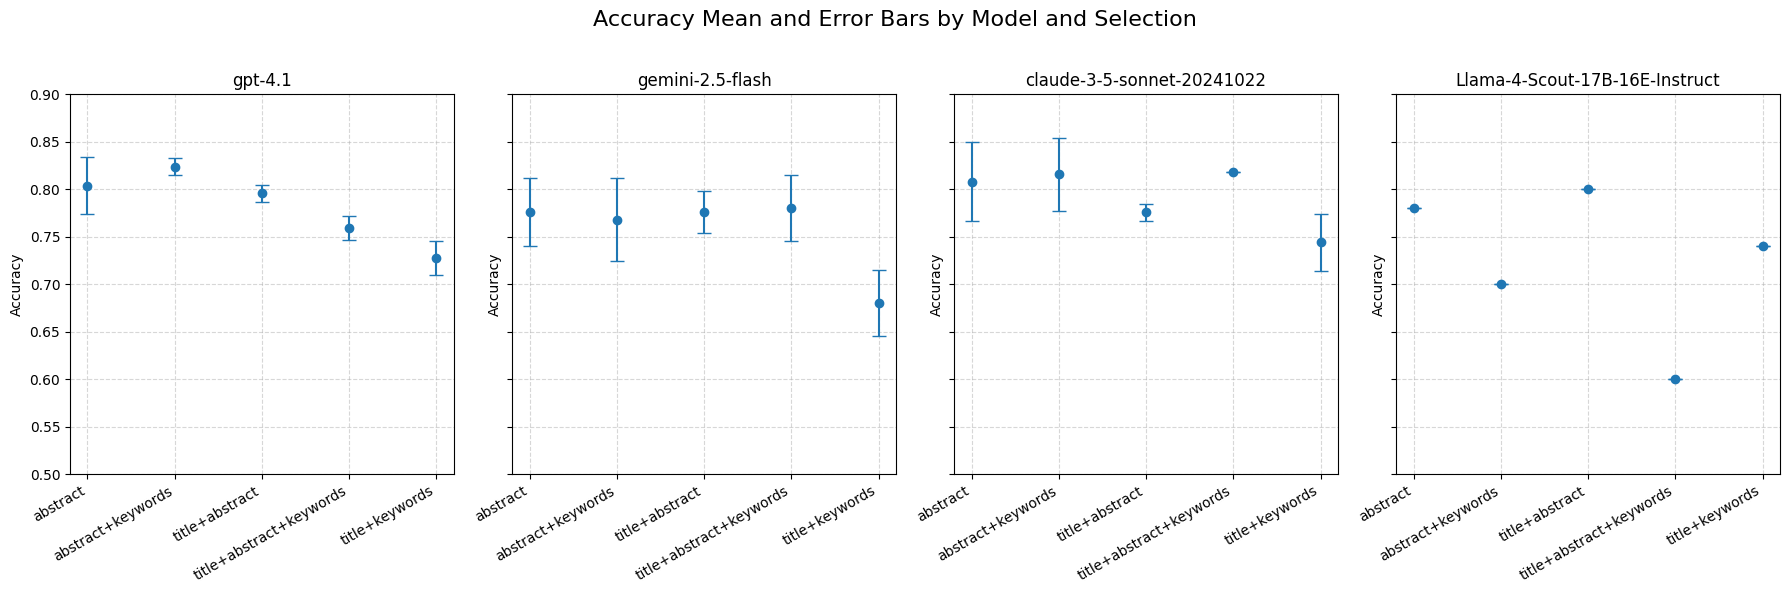

In [62]:

# Seleciona os três modelos principais
modelos_plot = ['gpt-4.1', 'gemini-2.5-flash', 'claude-3-5-sonnet-20241022','Llama-4-Scout-17B-16E-Instruct']
selections = df_summary['Selection'].unique()

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for idx, modelo in enumerate(modelos_plot):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]

    axes[idx].errorbar(x, y, yerr=yerr, fmt='o', capsize=5, label='Accuracy')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
    axes[idx].set_title(modelo)
    axes[idx].set_ylim(0.5, 0.9)
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Accuracy Mean and Error Bars by Model and Selection', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

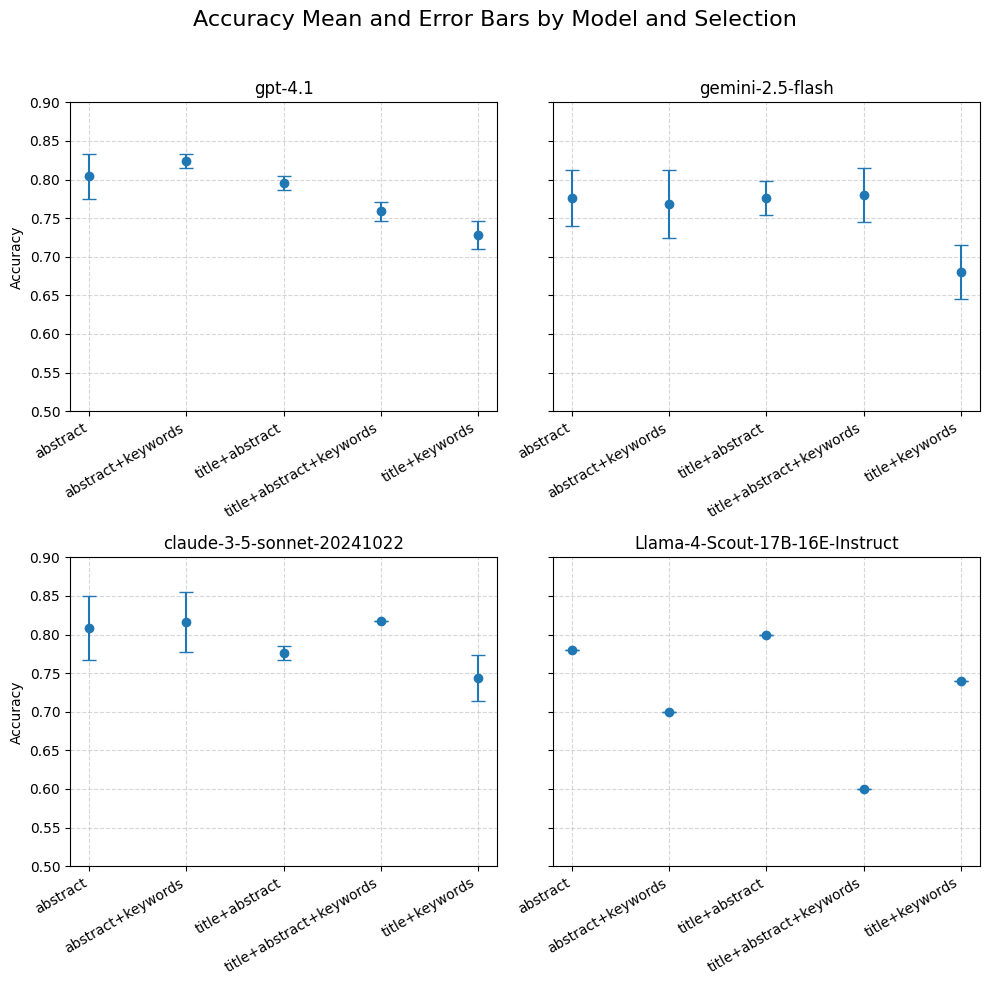

In [63]:
# Supondo que já existam: df_summary, np (NumPy) e plt (matplotlib.pyplot)

modelos_plot = ['gpt-4.1', 'gemini-2.5-flash', 'claude-3-5-sonnet-20241022','Llama-4-Scout-17B-16E-Instruct']

# Grade 2 x 2 em vez de 1 x 4
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)  # sharey para mesma escala no eixo Y
axes_flat = axes.flat  # vetoriza os eixos para indexação simples

for idx, modelo in enumerate(modelos_plot):
    ax = axes_flat[idx]
    df_plot = df_summary[df_summary['Model'] == modelo].copy()

    # Garantir ordem consistente de Selection (opcional)
    df_plot = df_plot.sort_values('Selection')
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean'].to_numpy()
    yerr = np.vstack([
        (y - df_plot['Accuracy_Lower'].to_numpy()),
        (df_plot['Accuracy_Upper'].to_numpy() - y)
    ])

    ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, label='Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
    ax.set_title(modelo)
    ax.set_ylim(0.5, 0.9)
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx in (0, 2):  # primeira coluna
        ax.set_ylabel('Accuracy')

# Se houver mais “slots” que modelos, desativa os eixos sobrando
for j in range(len(modelos_plot), 4):
    axes_flat[j].set_axis_off()

fig.suptitle('Accuracy Mean and Error Bars by Model and Selection', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


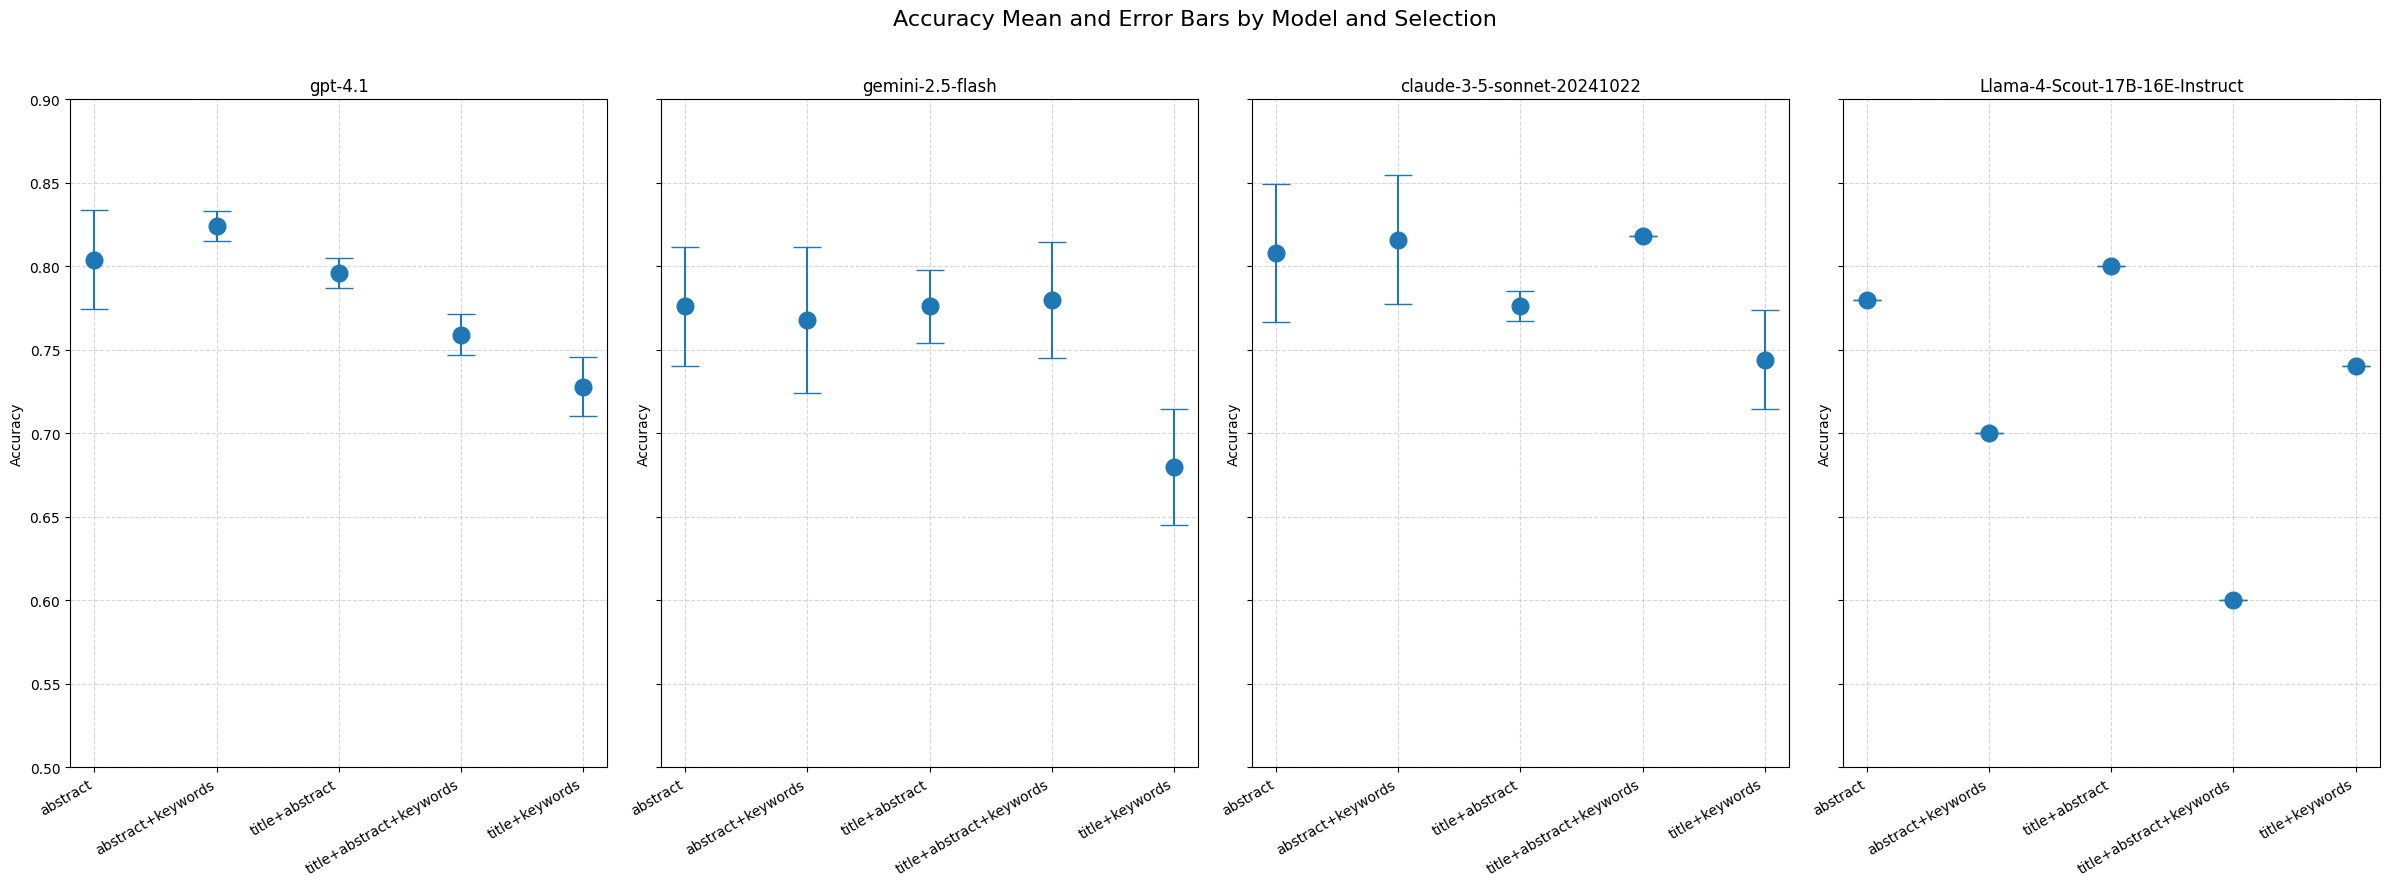

In [64]:
# Seleciona os três modelos principais
modelos_plot = ['gpt-4.1', 'gemini-2.5-flash', 'claude-3-5-sonnet-20241022','Llama-4-Scout-17B-16E-Instruct']
selections = df_summary['Selection'].unique()

fig, axes = plt.subplots(1, 4, figsize=(24, 9), sharey=True)

for idx, modelo in enumerate(modelos_plot):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]

    axes[idx].errorbar(x, y, yerr=yerr, fmt='o', capsize=10, label='Accuracy', markersize=12)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
    axes[idx].set_title(modelo)
    axes[idx].set_ylim(0.5, 0.9)
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Accuracy Mean and Error Bars by Model and Selection', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

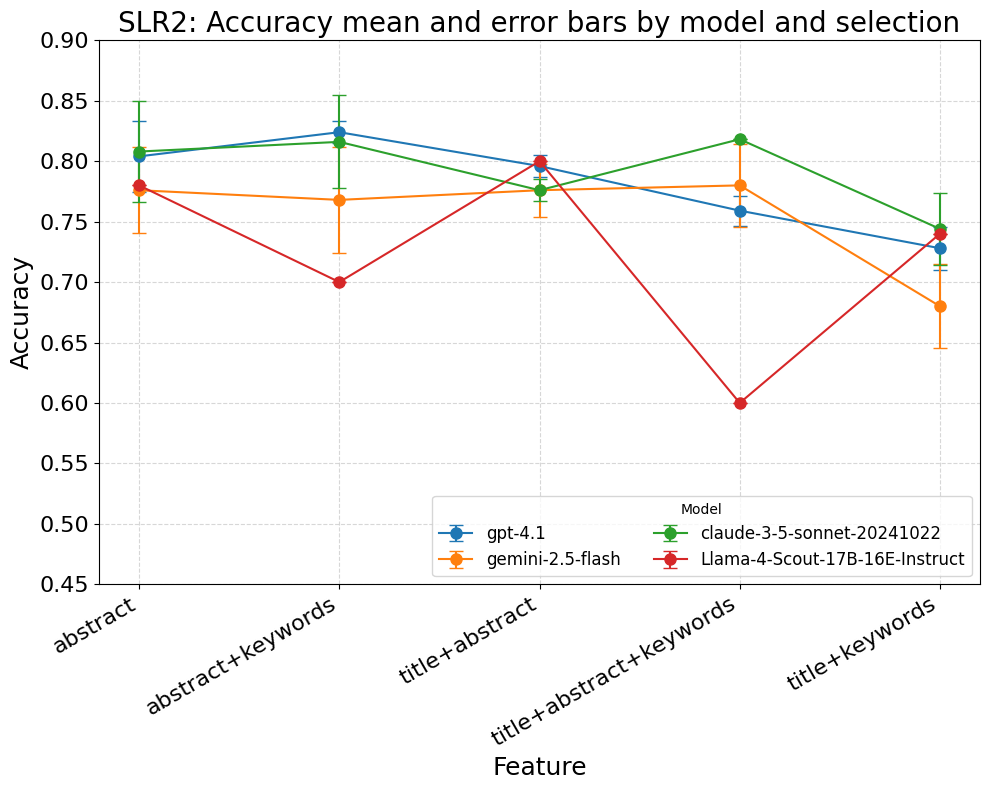

In [73]:
# Gráfico único com todas as séries de modelos em cores diferentes
modelos_plot = ['gpt-4.1', 'gemini-2.5-flash', 'claude-3-5-sonnet-20241022','Llama-4-Scout-17B-16E-Instruct']
colors = ['tab:blue', 'tab:orange', 'tab:green','tab:red']

fig, ax = plt.subplots(figsize=(10, 8))

for modelo, color in zip(modelos_plot, colors):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]
    ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5, label=modelo, color=color, markersize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
ax.set_ylabel('Accuracy', fontsize=18)
ax.set_ylim(0.45, 0.9)
ax.set_title('SLR2: Accuracy mean and error bars by model and selection', fontsize=20)

ax.set_xlabel('Feature', fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.grid(True, linestyle='--', alpha=0.5)


ax.legend(title='Model', fontsize=12,loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr2_fase_2_comparativo_modelos.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Gráfico único com todas as séries de modelos em cores diferentes (linha pontilhada)
modelos_plot = ['gpt-4.1', 'gemini-2.5-flash', 'claude-3-5-sonnet-20241022','Llama-4-Scout-17B-16E-Instruct']
colors = ['tab:blue', 'tab:orange', 'tab:green','tab:red']

fig, ax = plt.subplots(figsize=(10, 6))

for modelo, color in zip(modelos_plot, colors):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]
    ax.errorbar(x, y, yerr=yerr, fmt='o:', capsize=5, label=modelo, color=color, markersize=8)  # fmt='o:' para linha pontilhada

ax.set_xticks(x)
ax.set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 0.9)
ax.set_title('Accuracy mean and error bars by model and selection')
ax.legend(title='Model')
plt.tight_layout()
plt.show()

In [ ]:



# Boxplot para comparar a distribuição das acurácias por modelo e seleção
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_acuracia, x="Selection", y="Accuracy", hue="Model")
plt.title("Accuracy Distribution by Model and Selection Criteria")
plt.ylabel("Accuracy")
plt.xlabel("Selection")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Model")
plt.tight_layout()
plt.show()